In [1]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import numpy as np

/jet/home/hsun3/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/jet/home/hsun3/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# -----------------------------------------
# Fixed parameters
# -----------------------------------------
seasons = ["DJF", "JJA"]


In [3]:
# -----------------------------------------
# Function to read a 4-season dataset
# -----------------------------------------
def read_seasonal_dataset(files, value_col="z_mean"):
    seasonal_data = {}
    for season, f in zip(seasons, files):
        df = pd.read_csv(f, sep="\s+")
        da = df.pivot(index="lat", columns="lon", values=value_col)
        seasonal_data[season] = xr.DataArray(da.values,
                                             coords={"lat":da.index,"lon":da.columns},
                                             dims=["lat","lon"])
    return seasonal_data

# -----------------------------------------
# Load WMO 1st dataset
# -----------------------------------------
dataset = "era5_wmo_1st" # "era5_dyn" # 
files = [f"./Seasonal_Data/{dataset}_{s}.tab" for s in seasons]
seasonal_data = read_seasonal_dataset(files)

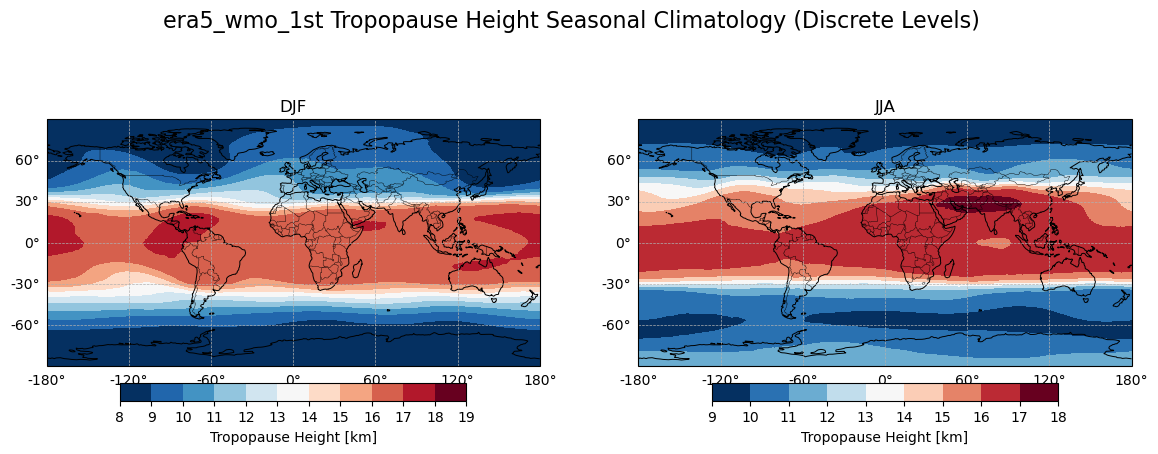

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

# Assume seasonal_data[season] is already loaded as xarray.DataArray

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), subplot_kw={"projection": ccrs.PlateCarree()})
axes = axes.flatten()

# Define colormaps and levels separately
cmap_list = ["RdBu_r", "RdBu_r"]
levels_list = [
    np.arange(8, 20, 1),  # DJF: blue, 10–15 km, 0.5 step
    np.arange(9, 19, 1)   # JJA: red, 15–18 km, 0.5 step
]

for ax, season, cmap_name, levels in zip(axes, seasons, cmap_list, levels_list):
    data = seasonal_data[season].values
    lats = seasonal_data[season].lat.values
    lons = seasonal_data[season].lon.values

    # Create ListedColormap and BoundaryNorm
    cmap = plt.get_cmap(cmap_name, len(levels)-1)
    norm = mcolors.BoundaryNorm(levels, cmap.N)

    # Plot
    im = ax.imshow(
        data,
        extent=[lons.min(), lons.max(), lats.min(), lats.max()],
        origin="lower",
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm
    )

    # Coastlines and borders
    ax.coastlines(linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

    # Gridlines with labels
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(range(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(range(-90, 91, 30))
    gl.xformatter = mticker.FuncFormatter(lambda x, _: f"{int(x)}°")
    gl.yformatter = mticker.FuncFormatter(lambda y, _: f"{int(y)}°")

    ax.set_title(season)

    # Independent colorbar
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.05, pad=0.05)
    cbar.set_label("Tropopause Height [km]")
    cbar.set_ticks(levels)  # show all levels

plt.suptitle(f"{dataset} Tropopause Height Seasonal Climatology (Discrete Levels)", fontsize=16)
plt.show()

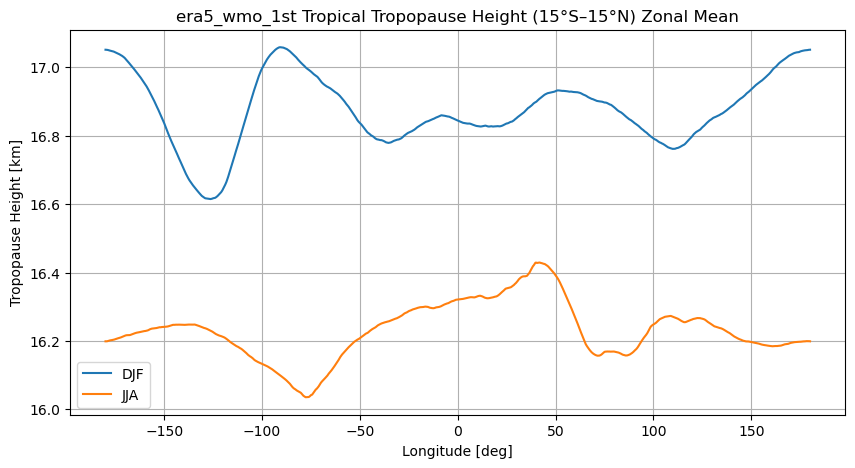

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# seasons
seasons = ["DJF", "JJA"]

# Dictionary to store tropical mean (15S–15N) for each season
tropical_means = {}

for season in seasons:
    # get seasonal data
    da = seasonal_data[season]  # xarray.DataArray with dims lat, lon
    
    # Select latitudes between -15 and 15
    da_tropics = da.sel(lat=slice(-15, -10))
    
    # Average over latitude to get zonal profile (lon dimension)
    zonal_profile = da_tropics.mean(dim="lat")
    
    # Store
    tropical_means[season] = pd.Series(zonal_profile.values, index=da.lon)

# Plot line figure
plt.figure(figsize=(10,5))
for season in seasons:
    plt.plot(tropical_means[season].index, tropical_means[season].values, label=season)

plt.xlabel("Longitude [deg]")
plt.ylabel("Tropopause Height [km]")
plt.title(f"{dataset} Tropical Tropopause Height (15°S–15°N) Zonal Mean")
plt.grid(True)
plt.legend()
plt.show()